<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/03-PyTorch-Object-Detection/01_R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy
import torch
import os
from detection_utils import intersection_over_union, non_max_suppression

!pip -q install selectivesearch
import selectivesearch
import cv2

In [3]:
import kagglehub
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

Using Colab cache for faster access to the 'pascal-voc-2007' dataset.


In [4]:
import os
import xml.etree.ElementTree as ET

annotations_dir = None
images_dir = None

#The dataset is very messy or we are auto finding the folder's or dir's path we needs
for root_dir, dirs, files in os.walk(path):
    if "Annotations" in dirs:
        annotations_dir = os.path.join(root_dir, "Annotations")
    if "JPEGImages" in dirs:
        images_dir = os.path.join(root_dir, "JPEGImages")

if not annotations_dir or not images_dir:
    raise FileNotFoundError("Could not find Annotations or JPEGImages folders in the dataset.")

print(f"Found Annotations at: {annotations_dir}")
print(f"Found Images at: {images_dir}")
print("-" * 50)

#Extracting only the three classes for this small experiment
target_classes = {"person", "dog", "car"}
filtered_dataset = []

for xml_filename in os.listdir(annotations_dir):
    if not xml_filename.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_filename)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_dir, filename)

    target_objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name in target_classes:
            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))

            target_objects.append({
                "class_name": class_name,
                "bbox": [xmin, ymin, xmax, ymax]
            })

    if len(target_objects) > 0:
        filtered_dataset.append({
            "image_path": image_path,
            "objects": target_objects
        })

print(f"Successfully processed {len(filtered_dataset)} images containing a person, dog, or car.")
print(f"Sample data: {filtered_dataset[0]}")

Found Annotations at: /kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007/VOCdevkit/VOC2007/Annotations
Found Images at: /kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages
--------------------------------------------------
Successfully processed 2878 images containing a person, dog, or car.
Sample data: {'image_path': '/kaggle/input/pascal-voc-2007/voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/006625.jpg', 'objects': [{'class_name': 'car', 'bbox': [284, 151, 319, 177]}, {'class_name': 'car', 'bbox': [120, 141, 179, 213]}, {'class_name': 'car', 'bbox': [17, 146, 111, 243]}, {'class_name': 'person', 'bbox': [102, 153, 152, 266]}, {'class_name': 'person', 'bbox': [69, 157, 100, 261]}, {'class_name': 'person', 'bbox': [19, 156, 58, 283]}]}


In [5]:
#Randomly picking 16 images with ground truth box for visuallization
# import random
# from google.colab.patches import cv2_imshow

# Loop for puting the box and class name on the img
# for i in range(16):
#   random_idx=random.randint(0,len(filtered_dataset))
#   img=cv2.imread(filtered_dataset[random_idx]["image_path"])
#   for obj in filtered_dataset[random_idx]["objects"]:
#     class_name = obj["class_name"]
#     bbox = obj["bbox"]
#     cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
#     cv2.putText(img, class_name, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

#   cv2_imshow(img)
#   cv2.waitKey(0)
#   cv2.destroyAllWindows()

<Figure size 1000x1000 with 0 Axes>

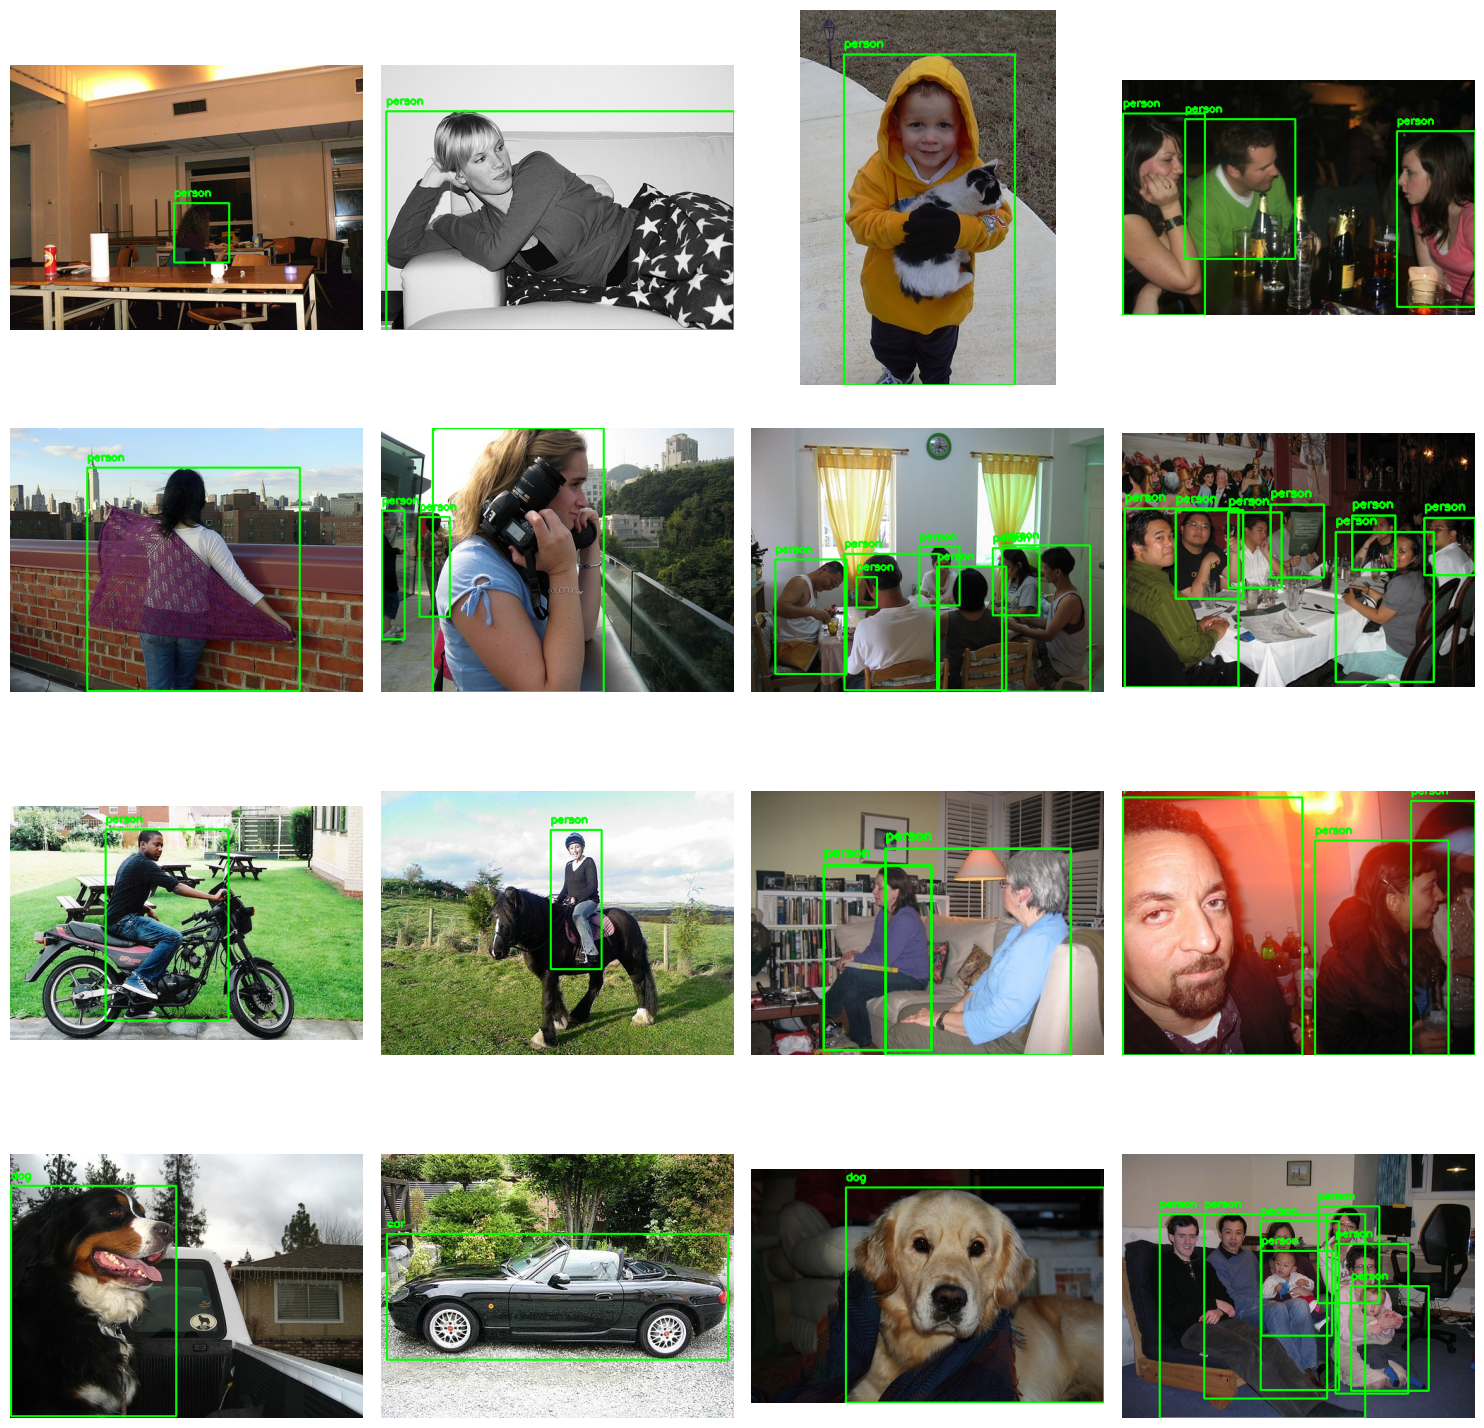

In [6]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 10))

sample_indices = random.sample(range(len(filtered_dataset)), 16) # Using the random.sample rather than randint for 16 unique indices

# Create a 4x4 grid for plot
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

#Adding all the ground truth boxes for each img for visualization
for idx, ax in zip(sample_indices, axes):
    img = cv2.imread(filtered_dataset[idx]["image_path"])

    for obj in filtered_dataset[idx]["objects"]:
        class_name = obj["class_name"]
        bbox = obj["bbox"]

        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img, class_name, (bbox[0], max(0, bbox[1] - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.axis("off")

plt.tight_layout()

sns.despine()
plt.show()

In [7]:
def extract_proposals(images,max_proposals=2000):
  '''
     images: cv2 images(H,W,C)
     max_proposals: int (max proposals per image default=2000)
  '''
  _,regions=selectivesearch.selective_search(images,scale=500,sigma=0.9,min_size=10)

  proposals=[]
  for r in regions:
    if r['rect'] == (0,0,images.shape[1],images.shape[0]):
      continue

    x,y,w,h=r['rect']
    if w>0 and h>0:
      proposals.append([x,y,x+w,y+h])

  proposals=list(set(tuple(x) for x in proposals))
  proposals=proposals[:max_proposals]

  return proposals[:max_proposals]

In [8]:
# Testing proposal extraction and cropping on a small subset
cropped_proposals = []

# Process the first 5 images for demonstration / debugging
for data in filtered_dataset[:5]:
    img = cv2.imread(data["image_path"])
    if img is None:
        continue

    proposal_boxes = extract_proposals(img, max_proposals=100)

    for box in proposal_boxes:
        x1, y1, x2, y2 = box

        # Crop proposed region
        crop = img[y1:y2, x1:x2]

        # Guard against zero-area crops
        if crop.size == 0 or crop.shape[0] == 0 or crop.shape[1] == 0:
            continue

        # Warp to 224x224 for CNN backbone
        warped_crop = cv2.resize(crop, (224, 224))
        cropped_proposals.append(warped_crop)

print(f"Extracted and warped {len(cropped_proposals)} regions ready for CNN.")

/usr/local/lib/python3.13/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Extracted and warped 500 regions ready for CNN.


In [ ]:
# picking one of the proposals and than croping /resizing it for CNN
import json

all_data=[]
output_file="rcnn_proposals_data.json"

for i in range(0,len(filtered_dataset)):
  img_path=filtered_dataset[i]["image_path"]
  img=cv2.imread(img_path)
  if img is None:
    continue

  croped_boxs= extract_proposals(img, max_proposals=500)

  all_data.append({
                  "image_path":img_path,
                  "croped_boxs":croped_boxs,
                  "ground_truth":filtered_dataset[i]["objects"]
                  })
  if (i + 1) % 25 == 0 or (i + 1) == len(filtered_dataset):
        print(f"Processed {i + 1}/{len(filtered_dataset)} images")

        with open(output_file, "w") as f:
            json.dump(all_data, f)

print(f"Successfully saved proposal data to {output_file}")

Processed 25/2878 images
Processed 50/2878 images
Processed 75/2878 images
Processed 100/2878 images
Processed 125/2878 images
Processed 150/2878 images
Processed 175/2878 images
Processed 200/2878 images
Processed 225/2878 images
Processed 250/2878 images
Processed 275/2878 images
Processed 300/2878 images
Processed 325/2878 images
Processed 350/2878 images
Processed 375/2878 images
Processed 400/2878 images
Processed 425/2878 images
Processed 450/2878 images
Processed 475/2878 images
Processed 500/2878 images
Processed 525/2878 images
Processed 550/2878 images
Processed 575/2878 images
Processed 600/2878 images
Processed 625/2878 images
Processed 650/2878 images
Processed 675/2878 images
Processed 700/2878 images
Processed 725/2878 images
Processed 750/2878 images
Processed 775/2878 images
Processed 800/2878 images
Processed 825/2878 images
Processed 850/2878 images
Processed 875/2878 images
Processed 900/2878 images
Processed 925/2878 images
Processed 950/2878 images
Processed 975/2